# TOR Presentation - XGBoost Directional Short-Term (t+5)

Notebook ini versi presentasi untuk stakeholder TOR INALUM.
Fokus: **kelayakan model short-term directional (t+5)** dengan evaluasi ketat dan insight keputusan.


## 1) Scope dan Pesan Utama

- Scope model: **short-term directional (up/down) t+5 trading-day**.
- Dataset: `ali_f_event_model_ready_v3.csv`.
- Baseline policy: baseline dipilih di valid dan di-lock ke test.
- Gate evaluasi: leakage, robustness antar fold, dan outperform baseline di test.
- Pesan utama: model **layak dipakai sebagai decision support arah jangka pendek**, bukan point-forecast return.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.calibration import calibration_curve

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_PATH = ROOT / "data" / "processed data" / "ali_f_event_model_ready_v3.csv"
ART_DIR = ROOT / "data" / "processed data"

FILES = {
    "decision": ART_DIR / "xgb_v5_directional_decision.json",
    "summary": ART_DIR / "xgb_v5_directional_cls_summary.csv",
    "robust": ART_DIR / "xgb_v5_directional_cls_robustness.csv",
    "ablation": ART_DIR / "xgb_v5_directional_ablation.csv",
    "pred": ART_DIR / "xgb_v5_directional_predictions.csv",
    "regime": ART_DIR / "xgb_v5_directional_regime_perf.csv",
}

missing = [k for k, p in FILES.items() if not p.exists()]
if missing:
    raise FileNotFoundError(f"Artifacts missing: {missing}. Jalankan XGBoost-v5-directional.ipynb dulu.")

with FILES["decision"].open() as f:
    decision = json.load(f)

summary_df = pd.read_csv(FILES["summary"])
robust_df = pd.read_csv(FILES["robust"])
ablation_df = pd.read_csv(FILES["ablation"])
pred_df = pd.read_csv(FILES["pred"])
regime_df = pd.read_csv(FILES["regime"])

df = pd.read_csv(DATA_PATH, parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)
pred_df["Date"] = pd.to_datetime(pred_df["Date"])

print("Loaded artifacts OK")
print("horizons in summary:", summary_df["horizon"].unique())
print("rows pred:", len(pred_df))


Loaded artifacts OK
horizons in summary: [5]
rows pred: 1337


In [2]:
# Executive KPI table (slide-ready)

kpi = pd.DataFrame([
    {
        "Model scope": "Directional t+5 (Close-based)",
        "Leakage pass": bool(decision.get("leakage_pass", False)),
        "Robustness pass": bool(decision.get("robustness_pass", False)),
        "Mean delta test acc": float(decision.get("mean_delta_test_acc", np.nan)),
        "Mean delta test acc (conf)": float(decision.get("mean_delta_test_acc_conf", np.nan)),
        "Overall GO": bool(decision.get("overall_go_shortterm_directional", False)),
        "Strict all horizons": bool(decision.get("strict_all_horizons", False)),
        "Feature set": decision.get("feature_set"),
        "Feature count": int(decision.get("feature_count", -1)),
        "Epsilon": float(decision.get("epsilon", np.nan)),
    }
])

kpi


,Model scope,Leakage pass,Robustness pass,Mean delta test acc,Mean delta test acc (conf),Overall GO,Strict all horizons,Feature set,Feature count,Epsilon
0,Directional t+5 (Close-based),True,True,0.00926,0.058898,True,False,top8_gain,8,0.0015


,rows,date_min,date_max,flat_ohlc_pct,long_gap_pct
0,2336,2014-05-06,2026-03-04,0.80351,0.012414


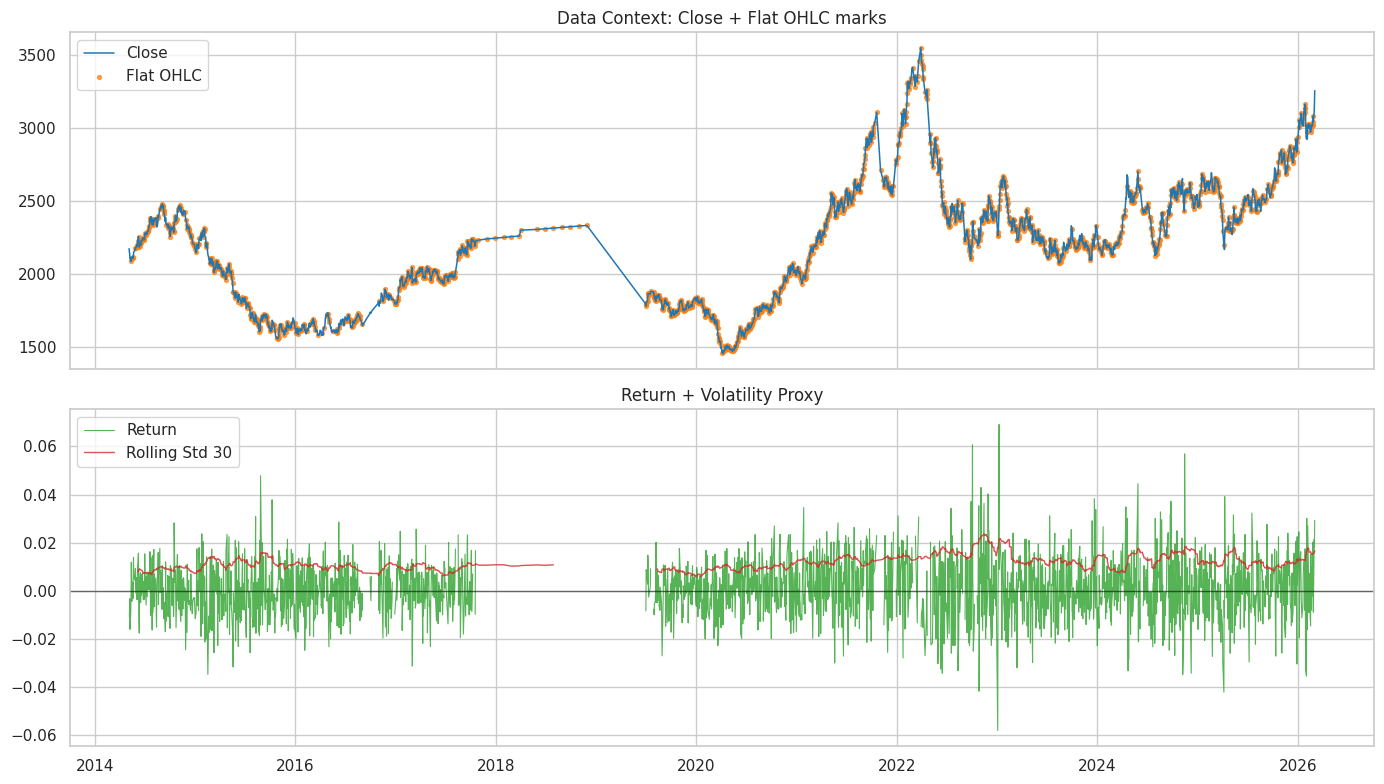

In [3]:
# Data quality context (untuk menjelaskan tantangan data)

df["is_flat_ohlc"] = (
    (df["Open"] == df["High"]) &
    (df["High"] == df["Low"]) &
    (df["Low"] == df["Close"])
)

df["ret_std_30"] = df["Return"].rolling(30, min_periods=20).std()

quality = pd.DataFrame([
    {
        "rows": len(df),
        "date_min": df["Date"].min().date(),
        "date_max": df["Date"].max().date(),
        "flat_ohlc_pct": float(df["is_flat_ohlc"].mean()),
        "long_gap_pct": float(df["is_long_gap"].fillna(False).mean()),
    }
])

display(quality)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df["Date"], df["Close"], color="#1f77b4", lw=1.1, label="Close")
flat = df[df["is_flat_ohlc"]]
if not flat.empty:
    axes[0].scatter(flat["Date"], flat["Close"], s=8, color="#ff7f0e", alpha=0.7, label="Flat OHLC")
axes[0].set_title("Data Context: Close + Flat OHLC marks")
axes[0].legend(loc="upper left")

axes[1].plot(df["Date"], df["Return"], color="#2ca02c", lw=0.8, alpha=0.8, label="Return")
axes[1].plot(df["Date"], df["ret_std_30"], color="#d62728", lw=1.0, alpha=0.8, label="Rolling Std 30")
axes[1].axhline(0, color="black", lw=1, alpha=0.5)
axes[1].set_title("Return + Volatility Proxy")
axes[1].legend(loc="upper left")

plt.tight_layout()
plt.show()


In [4]:
# Ringkasan performa utama vs baseline (valid & test)

view_cols = [
    "horizon", "folds", "valid_win_rate", "test_win_rate_locked",
    "strict_pass_rate", "mean_delta_valid_acc", "mean_delta_test_acc_locked", "mean_delta_test_acc_oracle"
]
summary_df[view_cols]


,horizon,folds,valid_win_rate,test_win_rate_locked,strict_pass_rate,mean_delta_valid_acc,mean_delta_test_acc_locked,mean_delta_test_acc_oracle
0,5,3,1.0,0.666667,0.666667,0.079037,0.00926,-0.009418


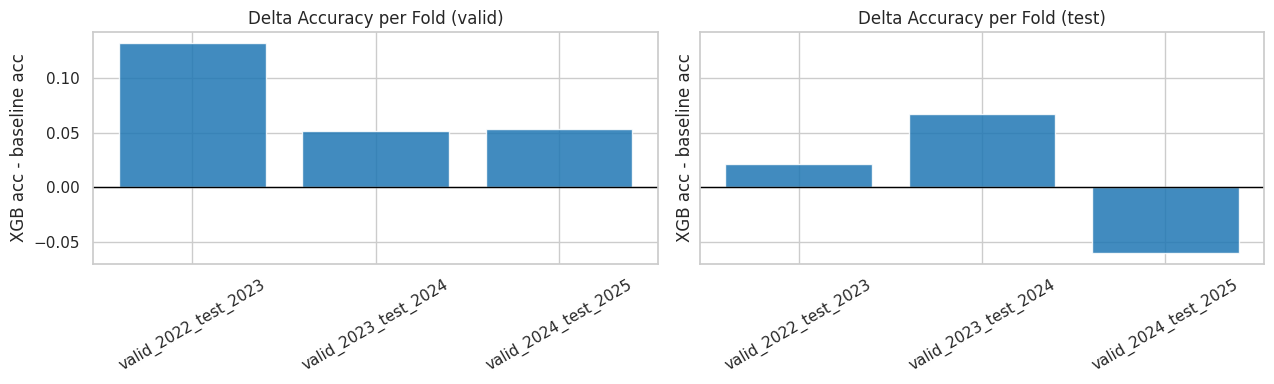

,horizon,fold_name,fold_order,split,xgb_acc,base_acc,avg_conf,delta_acc
0,5,valid_2022_test_2023,1,test,0.557940,0.536481,0.696428,0.021459
1,5,valid_2022_test_2023,1,valid,0.666667,0.534392,0.666667,0.132275
2,5,valid_2023_test_2024,2,test,0.591111,0.524444,0.628329,0.066667
3,5,valid_2023_test_2024,2,valid,0.587983,0.536481,0.587983,0.051502
4,5,valid_2024_test_2025,3,test,0.431034,0.491379,0.579059,-0.060345
5,5,valid_2024_test_2025,3,valid,0.577778,0.524444,0.577778,0.053333


In [5]:
# Fold-level deltas (visual utama presentasi)

fold_view = pred_df[["horizon", "fold_name", "fold_order", "split", "y_true", "y_pred", "baseline_pred", "confidence"]].copy()

agg = (
    fold_view
    .groupby(["horizon", "fold_name", "fold_order", "split"], as_index=False)
    .agg(
        xgb_acc=("y_pred", lambda s: float((s == fold_view.loc[s.index, "y_true"]).mean())),
        base_acc=("baseline_pred", lambda s: float((s == fold_view.loc[s.index, "y_true"]).mean())),
        avg_conf=("confidence", "mean"),
    )
)
agg["delta_acc"] = agg["xgb_acc"] - agg["base_acc"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for ax, split in zip(axes, ["valid", "test"]):
    d = agg[agg["split"] == split].sort_values("fold_order")
    ax.bar(d["fold_name"], d["delta_acc"], color="#1f77b4", alpha=0.85)
    ax.axhline(0, color="black", lw=1)
    ax.set_title(f"Delta Accuracy per Fold ({split})")
    ax.set_ylabel("XGB acc - baseline acc")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

agg


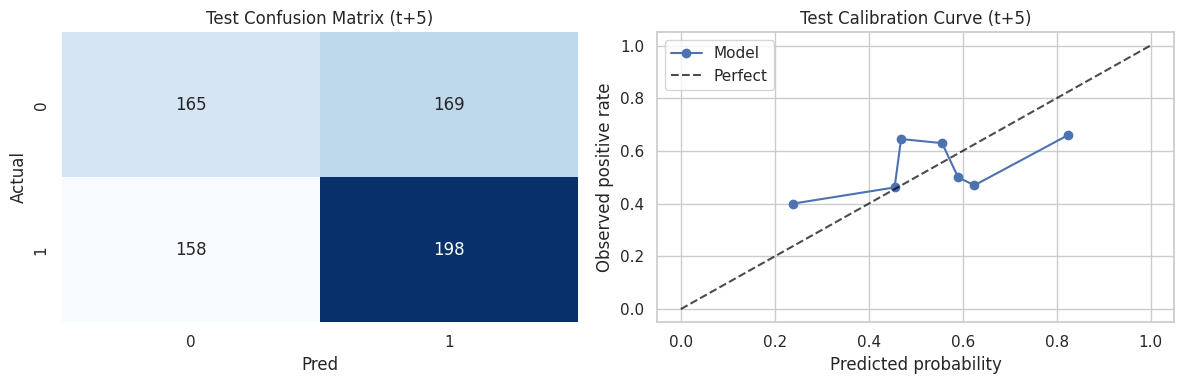

In [6]:
# Test confusion matrix + calibration (model reliability)

test_df = pred_df[pred_df["split"] == "test"].copy()

cm = confusion_matrix(test_df["y_true"], test_df["y_pred"], labels=[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0])
axes[0].set_title("Test Confusion Matrix (t+5)")
axes[0].set_xlabel("Pred")
axes[0].set_ylabel("Actual")

frac_pos, mean_pred = calibration_curve(test_df["y_true"], test_df["y_prob"], n_bins=10, strategy="quantile")
axes[1].plot(mean_pred, frac_pos, marker="o", label="Model")
axes[1].plot([0, 1], [0, 1], "--", color="black", alpha=0.7, label="Perfect")
axes[1].set_title("Test Calibration Curve (t+5)")
axes[1].set_xlabel("Predicted probability")
axes[1].set_ylabel("Observed positive rate")
axes[1].legend()

plt.tight_layout()
plt.show()


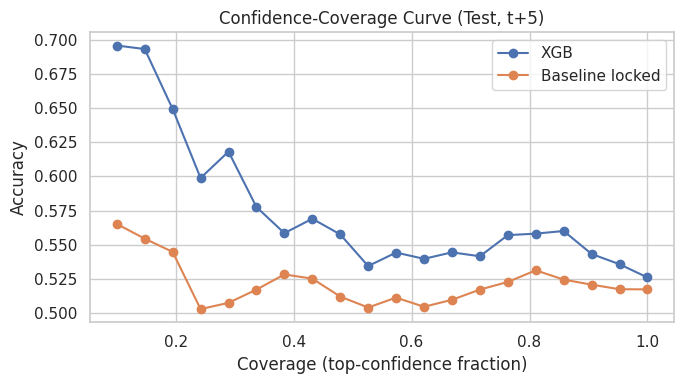

,coverage,xgb_acc,base_acc,delta_acc
0,0.100000,0.695652,0.565217,0.130435
1,0.147368,0.693069,0.554455,0.138614
2,0.194737,0.649254,0.544776,0.104478
3,0.242105,0.598802,0.502994,0.095808
4,0.289474,0.618090,0.507538,0.110553
5,0.336842,0.577586,0.517241,0.060345
6,0.384211,0.558491,0.528302,0.030189
7,0.431579,0.569024,0.525253,0.043771
8,0.478947,0.557576,0.512121,0.045455
9,0.526316,0.534435,0.504132,0.030303


In [7]:
# Confidence-Coverage curve: seberapa baik sinyal high-confidence

def confidence_curve(df_sub: pd.DataFrame, points: int = 20) -> pd.DataFrame:
    d = df_sub.sort_values("confidence", ascending=False).reset_index(drop=True)
    rows = []
    for c in np.linspace(0.1, 1.0, points):
        n = max(1, int(len(d) * c))
        part = d.iloc[:n]
        xgb_acc = float((part["y_pred"] == part["y_true"]).mean())
        base_acc = float((part["baseline_pred"] == part["y_true"]).mean())
        rows.append({
            "coverage": float(c),
            "xgb_acc": xgb_acc,
            "base_acc": base_acc,
            "delta_acc": xgb_acc - base_acc,
        })
    return pd.DataFrame(rows)

cc = confidence_curve(test_df)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(cc["coverage"], cc["xgb_acc"], marker="o", label="XGB")
ax.plot(cc["coverage"], cc["base_acc"], marker="o", label="Baseline locked")
ax.set_title("Confidence-Coverage Curve (Test, t+5)")
ax.set_xlabel("Coverage (top-confidence fraction)")
ax.set_ylabel("Accuracy")
ax.legend()
plt.tight_layout()
plt.show()

cc


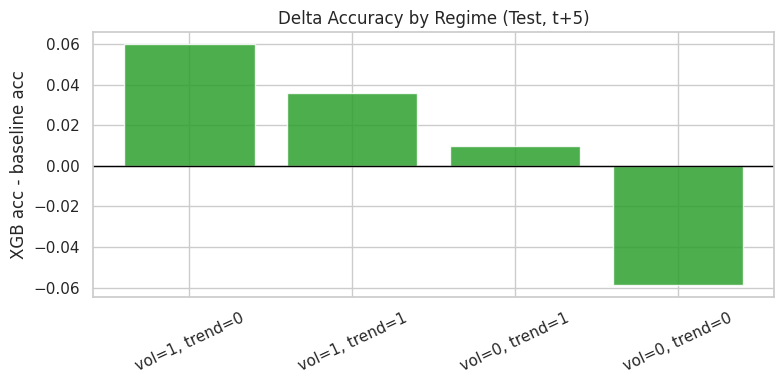

,regime_label,rows,xgb_acc,base_acc,delta_acc,avg_conf
0,"vol=1, trend=0",117,0.547009,0.487179,0.059829,0.615112
1,"vol=1, trend=1",195,0.558974,0.523077,0.035897,0.629788
2,"vol=0, trend=1",208,0.500000,0.490385,0.009615,0.608416
3,"vol=0, trend=0",170,0.505882,0.564706,-0.058824,0.686212


In [8]:
# Regime insight (kondisi market mana yang kuat/lemah)

reg = regime_df.copy()
reg["regime_label"] = reg.apply(
    lambda r: f"vol={int(r['vol_regime'])}, trend={int(r['trend_regime'])}",
    axis=1,
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(reg["regime_label"], reg["delta_acc"], color="#2ca02c", alpha=0.85)
ax.axhline(0, color="black", lw=1)
ax.set_title("Delta Accuracy by Regime (Test, t+5)")
ax.set_ylabel("XGB acc - baseline acc")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

reg[["regime_label", "rows", "xgb_acc", "base_acc", "delta_acc", "avg_conf"]]


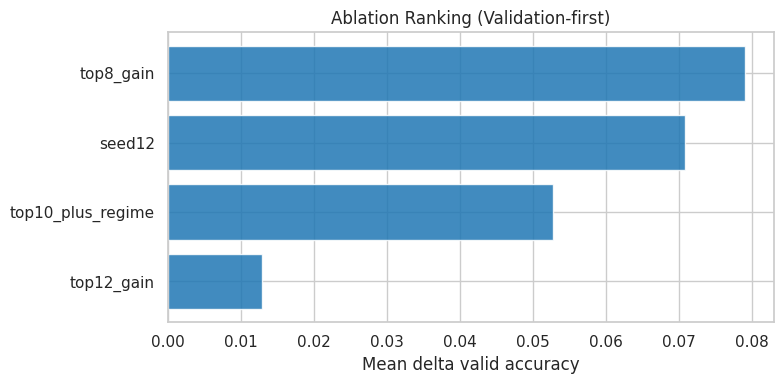

,feature_set,feature_count,mean_delta_valid_acc,mean_delta_test_acc,mean_delta_test_conf_acc,robust_all_horizons,strict_all_horizons
0,top8_gain,8,0.079037,0.009260,0.058898,True,False
1,seed12,12,0.070783,0.007925,0.024220,True,False
2,top10_plus_regime,12,0.052766,0.009225,0.027923,True,False
3,top12_gain,12,0.012864,0.005157,-0.017386,True,False


In [9]:
# Ablation slide (kenapa feature set final dipilih)

ablation_cols = [
    "feature_set", "feature_count", "mean_delta_valid_acc", "mean_delta_test_acc",
    "mean_delta_test_conf_acc", "robust_all_horizons", "strict_all_horizons"
]

ablation_show = ablation_df[ablation_cols].copy().sort_values("mean_delta_valid_acc", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
plot_df = ablation_show.sort_values("mean_delta_valid_acc", ascending=True)
ax.barh(plot_df["feature_set"], plot_df["mean_delta_valid_acc"], color="#1f77b4", alpha=0.85)
ax.set_title("Ablation Ranking (Validation-first)")
ax.set_xlabel("Mean delta valid accuracy")
plt.tight_layout()
plt.show()

ablation_show


In [10]:
# Final TOR decision block (slide-ready)

go = bool(decision.get("overall_go_shortterm_directional", False))
mean_delta_test = float(decision.get("mean_delta_test_acc", np.nan))
mean_delta_conf = float(decision.get("mean_delta_test_acc_conf", np.nan))

decision_text = pd.DataFrame([
    {
        "Kesimpulan": "GO (short-term directional t+5)" if go else "NO-GO",
        "Alasan utama": "Leakage pass + robust pass + test delta positif" if go else "Salah satu gate gagal",
        "Mean delta test acc": mean_delta_test,
        "Mean delta test acc (confidence slice)": mean_delta_conf,
        "Catatan": "Model untuk decision support arah, bukan point forecast harga/return.",
    }
])

decision_text


,Kesimpulan,Alasan utama,Mean delta test acc,Mean delta test acc (confidence slice),Catatan
0,GO (short-term directional t+5),Leakage pass + robust pass + test delta positif,0.00926,0.058898,"Model untuk decision support arah, bukan point..."


## 2) Rekomendasi Penyampaian ke Stakeholder

1. Klaim utama: model XGBoost directional **lulus untuk short-term t+5** sebagai decision support.
2. Jelaskan batasan: ini bukan model point forecast return/harga absolut.
3. Tunjukkan governance: leakage audit, baseline lock, dan robustness fold sudah dijalankan.
4. Tindak lanjut: deploy pilot terbatas dengan monitoring bulanan terhadap delta akurasi dan confidence drift.
